# Freight Rate Prediction

## 1. Setup and Data Loading

This notebook documents the data exploration, preprocessing, feature engineering, model development, validation strategy, and final prediction workflow for the freight rate prediction assessment.

In [1]:
# Import the libraries needed for data loading and analysis
import numpy as np
import pandas as pd

# Load the labeled development dataset
df = pd.read_csv("../data/train_test.csv")

df.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


## 2. Data Understanding and Quality

In [2]:
# Check the dataset structure, data types, missing values, and duplicate rows
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (48000, 14)

Data types:
load_id          object
pickup           object
delivery         object
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
equipment        object
weight          float64
date             object
market_index    float64
quote_signal    float64
posted_rate     float64
dtype: object

Missing values:
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

Duplicate rows: 0


### Data Quality Checks

In [3]:
# Check numeric ranges and identify potentially invalid values
print("Weight summary:")
print(df["weight"].describe())

print("\nNon-positive weights:", (df["weight"] <= 0).sum())

print("\nMarket index summary:")
print(df["market_index"].describe())

print("\nDistance summary:")
print(df["distance"].describe())

print("\nTarget summary:")
print(df["posted_rate"].describe())

Weight summary:
count    47700.000000
mean     31028.844004
std       9391.440620
min     -47500.000000
25%      25800.000000
50%      31436.500000
75%      37018.000000
max      47500.000000
Name: weight, dtype: float64

Non-positive weights: 292

Market index summary:
count    47626.000000
mean         1.083387
std          0.168091
min          0.676390
25%          0.949670
50%          1.055800
75%          1.219590
max          1.467780
Name: market_index, dtype: float64

Distance summary:
count    48000.000000
mean      1135.856654
std        728.564416
min         70.000000
25%        550.400000
50%        953.300000
75%       1645.525000
max       3439.800000
Name: distance, dtype: float64

Target summary:
count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64


### Date and Categorical Features

In [4]:
# Inspect the time range and the number of unique categorical values
df["date"] = pd.to_datetime(df["date"])

print("Date range:")
print(df["date"].min(), "to", df["date"].max())

print("\nUnique values:")
print("Pickup locations:", df["pickup"].nunique())
print("Delivery locations:", df["delivery"].nunique())
print("Equipment types:", df["equipment"].nunique())

print("\nEquipment distribution:")
print(df["equipment"].value_counts())

Date range:
2025-01-01 00:00:00 to 2025-10-31 00:00:00

Unique values:
Pickup locations: 64
Delivery locations: 64
Equipment types: 3

Equipment distribution:
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64


### Target Distribution

In [5]:
# Measure target skewness and inspect rate ranges
print("Target skewness:", df["posted_rate"].skew())

print("\nTarget quantiles:")
print(df["posted_rate"].quantile([0.01, 0.25, 0.50, 0.75, 0.99]))

Target skewness: 1.9023948792201801

Target quantiles:
0.01     327.1688
0.25    1251.5550
0.50    2030.7600
0.75    3330.7500
0.99    5972.8340
Name: posted_rate, dtype: float64


## 3. Time-Based Validation Strategy

Because the goal is to predict future freight loads, a time-based split was used instead of a random split. Data from January through September 2025 is used for training, while October 2025 is held out as the validation period.

In [6]:
# Split the labeled data chronologically to simulate future prediction
train_df = df[df["date"] < "2025-10-01"].copy()
val_df = df[df["date"] >= "2025-10-01"].copy()

print("Training period:", train_df["date"].min(), "to", train_df["date"].max())
print("Validation period:", val_df["date"].min(), "to", val_df["date"].max())

print("\nTraining shape:", train_df.shape)
print("Validation shape:", val_df.shape)

Training period: 2025-01-01 00:00:00 to 2025-09-30 00:00:00
Validation period: 2025-10-01 00:00:00 to 2025-10-31 00:00:00

Training shape: (43147, 14)
Validation shape: (4853, 14)


## 4. Data Cleaning and Feature Engineering

### Handling Missing and Invalid Values

In [7]:
# Treat non-positive weights as missing and impute using the training median
train_df.loc[train_df["weight"] <= 0, "weight"] = pd.NA
val_df.loc[val_df["weight"] <= 0, "weight"] = pd.NA

weight_median = train_df["weight"].median()

train_df["weight"] = train_df["weight"].fillna(weight_median)
val_df["weight"] = val_df["weight"].fillna(weight_median)

print("Training weight median:", weight_median)
print("Remaining missing weights:", train_df["weight"].isna().sum(), val_df["weight"].isna().sum())

Training weight median: 31492.0
Remaining missing weights: 0 0


### Handling Missing Market Index

In [8]:
# Impute missing market index values using the training median
market_index_median = train_df["market_index"].median()

train_df["market_index"] = train_df["market_index"].fillna(market_index_median)
val_df["market_index"] = val_df["market_index"].fillna(market_index_median)

print("Training market index median:", market_index_median)
print(
    "Remaining missing values:",
    train_df["market_index"].isna().sum(),
    val_df["market_index"].isna().sum()
)

Training market index median: 1.08317
Remaining missing values: 0 0


### Date Features

In [ ]:
# Extract calendar features that may capture time-related pricing patterns
for data in [train_df, val_df]:
    data["month"] = data["date"].dt.month
    data["day_of_week"] = data["date"].dt.dayofweek

train_df[["date", "month", "day_of_week"]].head()

,date,month,day_of_week
0,2025-01-01,1,2
1,2025-01-01,1,2
2,2025-01-01,1,2
3,2025-01-01,1,2
4,2025-01-01,1,2


### Geographic Features

In [12]:
# Capture the latitude and longitude differences between pickup and delivery
for data in [train_df, val_df]:
    data["lat_diff"] = data["delivery_lat"] - data["pickup_lat"]
    data["lon_diff"] = data["delivery_lon"] - data["pickup_lon"]

train_df[["pickup_lat", "delivery_lat", "lat_diff",
          "pickup_lon", "delivery_lon", "lon_diff"]].head()

,pickup_lat,delivery_lat,lat_diff,pickup_lon,delivery_lon,lon_diff
0,38.09122,38.16908,0.07786,-76.78906,-72.74564,4.04342
1,38.09122,39.22317,1.13195,-76.78906,-72.96710,3.82196
2,39.22317,44.30296,5.07979,-72.96710,-87.52871,-14.56161
3,39.55328,34.84933,-4.70395,-72.18051,-86.28940,-14.10889
4,31.83025,35.29479,3.46454,-94.38343,-88.08915,6.29428


### Route Feature

In [13]:
# Combine pickup and delivery locations into a single route identifier
for data in [train_df, val_df]:
    data["route"] = data["pickup"] + " → " + data["delivery"]

train_df["route"].head()

0        Richmond → Baltimore
1     Richmond → Philadelphia
2    Philadelphia → Green Bay
3          Hartford → Atlanta
4          Dallas → Nashville
Name: route, dtype: object

### Final Feature Set

The final feature set combines route, location, shipment, market, and time-related information while excluding identifiers and the raw date column.

In [14]:
# Define the target and the features used by the models
target = "posted_rate"

features = [
    "pickup",
    "delivery",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "equipment",
    "weight",
    "market_index",
    "quote_signal",
    "month",
    "day_of_week",
    "lat_diff",
    "lon_diff",
    "route"
]

categorical_features = [
    "pickup",
    "delivery",
    "equipment",
    "route"
]

numeric_features = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "month",
    "day_of_week",
    "lat_diff",
    "lon_diff"
]

print("Number of features:", len(features))
print("Categorical features:", len(categorical_features))
print("Numeric features:", len(numeric_features))

Number of features: 16
Categorical features: 4
Numeric features: 12


### Model Preprocessing

In [15]:
# Encode categorical features and keep numeric features unchanged
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

### Training and Validation Data

In [16]:
# Separate model inputs from the target for training and validation
X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (43147, 16)
y_train: (43147,)
X_val: (4853, 16)
y_val: (4853,)


## 5. Model Development and Comparison

Several regression models were evaluated using the same time-based validation set. Mean Absolute Error (MAE) was used as the primary metric, with RMSE as a secondary metric.

### 5.1 Decision Tree Baseline

In [17]:
# Train a simple tree-based regression model as the baseline
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=10,
            random_state=42
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

tree_predictions = decision_tree_model.predict(X_val)

tree_mae = mean_absolute_error(y_val, tree_predictions)
tree_rmse = np.sqrt(mean_squared_error(y_val, tree_predictions))

print("Decision Tree MAE:", tree_mae)
print("Decision Tree RMSE:", tree_rmse)

Decision Tree MAE: 198.18055320443582
Decision Tree RMSE: 927.7930876536836


### 5.2 Random Forest

In [21]:
# Train a Random Forest to improve on the single-tree baseline
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_val)

rf_mae = mean_absolute_error(y_val, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_predictions))

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 167.99855370606983
Random Forest RMSE: 725.1836581220075


### 5.3 HistGradientBoosting

In [22]:
# Train a gradient boosting model to capture more complex pricing patterns
from sklearn.ensemble import HistGradientBoostingRegressor

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingRegressor(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)

gradient_boosting_model.fit(X_train, y_train)

gb_predictions = gradient_boosting_model.predict(X_val)

gb_mae = mean_absolute_error(y_val, gb_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_val, gb_predictions))

print("HistGradientBoosting MAE:", gb_mae)
print("HistGradientBoosting RMSE:", gb_rmse)

HistGradientBoosting MAE: 133.78764066275755
HistGradientBoosting RMSE: 655.7825998499499


### 5.4 HistGradientBoosting with Log-Transformed Target

Because the target distribution is right-skewed and contains high-rate observations, the target was log-transformed using `log1p` during training. Predictions were converted back to the original scale using `expm1`.

In [23]:
# Train the model on a log-transformed target to reduce the effect of high-rate values
y_train_log = np.log1p(y_train)

gradient_boosting_log_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingRegressor(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)

gradient_boosting_log_model.fit(X_train, y_train_log)

log_predictions = gradient_boosting_log_model.predict(X_val)

# Convert predictions back to the original rate scale
log_predictions = np.expm1(log_predictions)

log_gb_mae = mean_absolute_error(y_val, log_predictions)
log_gb_rmse = np.sqrt(mean_squared_error(y_val, log_predictions))

print("Log-Transformed HistGradientBoosting MAE:", log_gb_mae)
print("Log-Transformed HistGradientBoosting RMSE:", log_gb_rmse)

Log-Transformed HistGradientBoosting MAE: 114.5590183622781
Log-Transformed HistGradientBoosting RMSE: 650.9345293183842


### 5.5 Model Comparison

In [26]:
# Summarize validation performance across the evaluated models
model_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "HistGradientBoosting",
        "HistGradientBoosting + Log Target"
    ],
    "MAE": [
        tree_mae,
        rf_mae,
        gb_mae,
        log_gb_mae
    ],
    "RMSE": [
        tree_rmse,
        rf_rmse,
        gb_rmse,
        log_gb_rmse
    ]
})

model_results = model_results.round(2)
model_results.style.hide(axis="index")

Model,MAE,RMSE
Decision Tree,198.180000,927.790000
Random Forest,168.000000,725.180000
HistGradientBoosting,133.790000,655.780000
HistGradientBoosting + Log Target,114.560000,650.930000


### 5.6 Selected Model

The HistGradientBoosting model trained on the log-transformed target achieved the lowest validation MAE and was selected as the final model.

In [27]:
# Select the best-performing model based on validation MAE
final_model = gradient_boosting_log_model

print("Selected model: HistGradientBoosting + Log Target")
print("Validation MAE:", round(log_gb_mae, 2))
print("Validation RMSE:", round(log_gb_rmse, 2))

Selected model: HistGradientBoosting + Log Target
Validation MAE: 114.56
Validation RMSE: 650.93


## 6. Final Model Training

The selected model is retrained on the complete labeled dataset so that all available historical observations can be used before generating predictions for the unseen validation loads.

### Preparing the Full Training Dataset

In [28]:
# Prepare the complete labeled dataset using the same cleaning and feature engineering steps
final_df = df.copy()

# Treat non-positive weights as missing
final_df.loc[final_df["weight"] <= 0, "weight"] = pd.NA

# Impute using the median calculated from the full labeled dataset
final_weight_median = final_df["weight"].median()
final_market_index_median = final_df["market_index"].median()

final_df["weight"] = final_df["weight"].fillna(final_weight_median)
final_df["market_index"] = final_df["market_index"].fillna(final_market_index_median)

# Create the same date and route features used during validation
final_df["month"] = final_df["date"].dt.month
final_df["day_of_week"] = final_df["date"].dt.dayofweek
final_df["lat_diff"] = final_df["delivery_lat"] - final_df["pickup_lat"]
final_df["lon_diff"] = final_df["delivery_lon"] - final_df["pickup_lon"]
final_df["route"] = final_df["pickup"] + " → " + final_df["delivery"]

print("Final dataset shape:", final_df.shape)
print("Remaining missing values:", final_df[features].isna().sum().sum())

Final dataset shape: (48000, 19)
Remaining missing values: 0


### Final Training Data

In [29]:
# Separate the full feature set from the target for final training
X_final = final_df[features]
y_final = final_df[target]

print("X_final:", X_final.shape)
print("y_final:", y_final.shape)

X_final: (48000, 16)
y_final: (48000,)


### Training the Final Model

In [30]:
# Train the selected model on all labeled observations using the log-transformed target
y_final_log = np.log1p(y_final)

final_model.fit(X_final, y_final_log)

print("Final model trained on:", len(X_final), "observations")

Final model trained on: 48000 observations


## 7. Final Validation Predictions

The final model is used to predict freight rates for the unseen validation loads provided by the assessment.

### Preparing the Unseen Validation Data

In [31]:
# Load and prepare the unseen validation dataset
validation_df = pd.read_csv("../data/validation.csv")
validation_df["date"] = pd.to_datetime(validation_df["date"])

print("Validation shape:", validation_df.shape)
print("Date range:", validation_df["date"].min(), "to", validation_df["date"].max())

Validation shape: (12000, 13)
Date range: 2025-11-01 00:00:00 to 2025-12-31 00:00:00


### Applying Final Preprocessing

In [32]:
# Apply the same preprocessing and feature engineering used during training
validation_df.loc[validation_df["weight"] <= 0, "weight"] = pd.NA

validation_df["weight"] = validation_df["weight"].fillna(final_weight_median)
validation_df["market_index"] = validation_df["market_index"].fillna(final_market_index_median)

validation_df["month"] = validation_df["date"].dt.month
validation_df["day_of_week"] = validation_df["date"].dt.dayofweek

validation_df["lat_diff"] = validation_df["delivery_lat"] - validation_df["pickup_lat"]
validation_df["lon_diff"] = validation_df["delivery_lon"] - validation_df["pickup_lon"]

validation_df["route"] = (
    validation_df["pickup"] + " → " + validation_df["delivery"]
)

print("Remaining missing values:", validation_df[features].isna().sum().sum())
print("Validation features:", validation_df[features].shape)

Remaining missing values: 0
Validation features: (12000, 16)


### Generating Final Predictions

In [33]:
# Generate predictions for the unseen validation loads and convert them back to the original rate scale
validation_log_predictions = final_model.predict(validation_df[features])

validation_predictions = np.expm1(validation_log_predictions)

print("Number of predictions:", len(validation_predictions))
print("Minimum predicted rate:", validation_predictions.min())
print("Maximum predicted rate:", validation_predictions.max())
print("Mean predicted rate:", validation_predictions.mean())

Number of predictions: 12000
Minimum predicted rate: 213.44950871752545
Maximum predicted rate: 6655.7189231664
Mean predicted rate: 2352.3118373876177


### Creating the Prediction File

In [34]:
# Create the final prediction file using the required load IDs and prediction column
validation_predictions_df = pd.DataFrame({
    "load_id": validation_df["load_id"],
    "predicted_rate": validation_predictions
})

validation_predictions_df.to_csv(
    "../validation_predictions.csv",
    index=False
)

print("Prediction file shape:", validation_predictions_df.shape)
print("Missing predictions:", validation_predictions_df["predicted_rate"].isna().sum())

validation_predictions_df.head()

Prediction file shape: (12000, 2)
Missing predictions: 0


,load_id,predicted_rate
0,TE-000001,833.181266
1,TE-000002,5094.577813
2,TE-000003,5231.654788
3,TE-000004,4025.045852
4,TE-000005,1812.754293


## 8. December Scenario

The December scenario evaluates the final model on a fixed Lexington-to-Fort Wayne route across December 2025.

In [35]:
# Load the fixed December scenario provided for the assessment
december_df = pd.read_csv("../data/december_chart_inputs.csv")

print("December scenario shape:", december_df.shape)
print("\nColumns:")
print(december_df.columns.tolist())

december_df.head()

December scenario shape: (31, 7)

Columns:
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,842.193618
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,842.193618
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,842.193618
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,842.193618
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,842.193618


### Preparing the December Scenario

In [36]:
# Prepare the December scenario using the same features used by the final model
december_df["date"] = pd.to_datetime(december_df["date"])

december_df["month"] = december_df["date"].dt.month
december_df["day_of_week"] = december_df["date"].dt.dayofweek

december_df["lat_diff"] = 0
december_df["lon_diff"] = 0

december_df["route"] = (
    december_df["pickup"] + " → " + december_df["delivery"]
)

# Use the training median for the quote signal in the fixed scenario
december_df["quote_signal"] = final_df["quote_signal"].median()

print("December features prepared.")
print("Quote signal used:", december_df["quote_signal"].iloc[0])

December features prepared.
Quote signal used: 2.05575


### Generating December Predictions

In [41]:
# Generate predictions for the fixed December scenario
december_log_predictions = final_model.predict(december_df[features])

december_predictions = np.expm1(december_log_predictions)

december_df["predicted_rate"] = december_predictions

print("Number of December predictions:", len(december_predictions))
print("Minimum predicted rate:", december_predictions.min())
print("Maximum predicted rate:", december_predictions.max())
print("Mean predicted rate:", december_predictions.mean())

Number of December predictions: 31
Minimum predicted rate: 840.0229383170783
Maximum predicted rate: 842.1936175338836
Mean predicted rate: 841.9135298930057


In [42]:
# Review the December dates and predicted rates before creating the chart
december_df[["date", "predicted_rate"]]

,date,predicted_rate
0,2025-12-01,842.193618
1,2025-12-02,842.193618
2,2025-12-03,842.193618
3,2025-12-04,842.193618
4,2025-12-05,842.193618
5,2025-12-06,842.193618
6,2025-12-07,840.022938
7,2025-12-08,842.193618
8,2025-12-09,842.193618
9,2025-12-10,842.193618


### December Prediction Chart

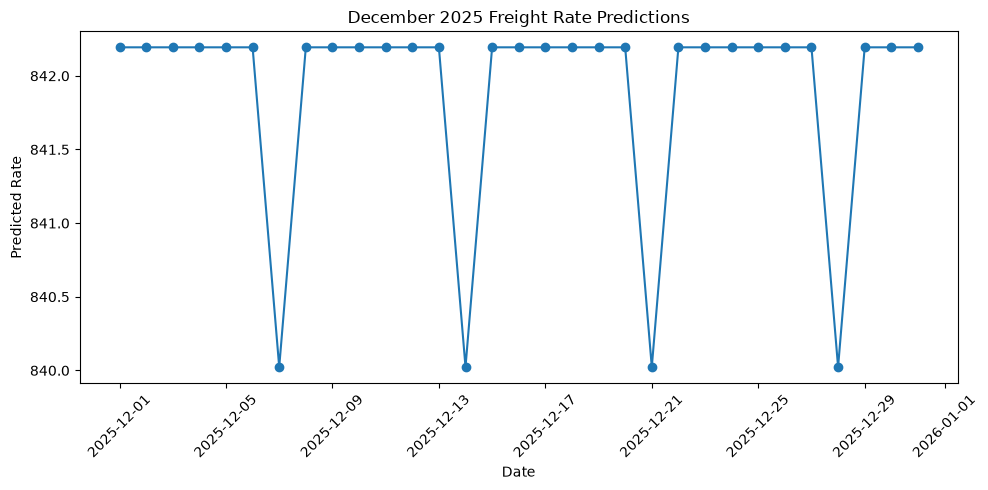

In [43]:
# Create the December prediction chart required by the assessment
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    december_df["date"],
    december_df["predicted_rate"],
    marker="o"
)

plt.title("December 2025 Freight Rate Predictions")
plt.xlabel("Date")
plt.ylabel("Predicted Rate")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../scorer_results/candidate_december.png", dpi=150)
plt.show()

### Final Assessment Verification

In [44]:
# Verify that the required prediction files and outputs are ready
import os

prediction_file = "../validation_predictions.csv"
december_chart = "../scorer_results/candidate_december.png"

print("Validation predictions file exists:", os.path.exists(prediction_file))
print("December chart exists:", os.path.exists(december_chart))

print("\nValidation predictions:")
print(validation_predictions_df.shape)
print("Missing predictions:", validation_predictions_df["predicted_rate"].isna().sum())

print("\nDecember predictions:")
print("Number of predictions:", len(december_df))
print("Missing predictions:", december_df["predicted_rate"].isna().sum())

Validation predictions file exists: True
December chart exists: True

Validation predictions:
(12000, 2)
Missing predictions: 0

December predictions:
Number of predictions: 31
Missing predictions: 0
